# Radar Cross Section (RCS) Analysis of a Trihedral Corner Reflector
### Cross-Exclusion Clutter Window Variant (Garthwaite et al., 2015, Figure 4.11 / Table 4.5)

**Target location:** GCP03 (ITS Surabaya)
**Sensor:** Sentinel-1A IW SLC → Terrain Corrected (Orb_tnr_Cal_[split_]deb_TC)
**Method:** CoRAL (Corner Reflector Analysis Library), Geoscience Australia

---
This notebook performs the following steps:
1. Reading all SAR scenes available in the target directory, including both full-swath and IW-subswath-split products
2. Automatic detection of the correct Sigma0 band for each scene (full-swath vs. split subswath products may use different band names)
3. Conversion of the CR reference coordinates (UTM → geographic)
4. Automatic search for the sigma0 peak pixel around the reference point
5. Computation of RCS and SCR per scene using CoRAL
6. Summary of the results as a table and as time-series visualizations


## 1. Configuration and Library Imports

In [1]:
import glob
import os
import re
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from rasterio.transform import rowcol
from rasterio.windows import Window
from pyproj import Transformer
import xml.etree.ElementTree as ET

import coral.dataio as dataio_module
from coral.corner_reflector import loop
from coral.cross_exclusion import loop_cross_exclusion

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.dpi": 120,
})

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Input Parameters

All parameters that need to be adjusted by the user are collected in a single place.

**Note on the dataset structure:** the target directory may contain a mix of two product types:
- **Full-swath** products (`*_Orb_tnr_Cal_deb_TC.data`), which store the calibrated band as `Sigma0_VV`.
- **Split** products (`*_Orb_tnr_Cal_split_deb_TC.data`), which have been limited to a single IW subswath (e.g. IW1) prior to terrain correction, and therefore store the band as `Sigma0_IW1_VV` (or `IW2`/`IW3`, depending on which subswath contains the target).

Because the band name differs between these two product types, `BAND_NAME` below is treated only as the **preferred polarization identifier** (`VV`); the actual band name is resolved automatically per scene in Section 3.

In [3]:
# --- Data path ---
DATA_DIR = "/media/geospasial/storage_2/TESISZAKI/Radiometric/Database/ASC old"
OUTPUT_DIR = "/media/geospasial/storage_2/TESISZAKI/Radiometric/CoRAL-modif"
POLARIZATION = "VV"   # used to auto-detect the Sigma0 band name per scene (see Section 3)

# --- Ground control point (GCP03) reference coordinates, UTM zone 49S ---
GCP_NAME = "GCP03"
GCP_EASTING = 698162.7296
GCP_NORTHING = 9194891.1360
GCP_HEIGHT = 32.1755
GCP_EPSG = "EPSG:32749"   # UTM zone 49S

# --- Sigma0 peak search parameters ---
SEARCH_RADIUS_M = 50      # search radius around the reference point (meters)

# --- CoRAL analysis window parameters ---
SUB_IM = 51                  # half-size of the image crop (pixels)
TARG_WIN_SZ = 4              # target (CR) window size (pixels)
CLT_WIN_SZ = 32              # clutter window size (pixels)
CROSS_WIDTH = 5              # cross-exclusion width (pixels), Table 4.5 Garthwaite et al. (2015), C-band 1.5 m CR

# --- Fallback incidence angle (for Terrain Corrected products without a tie-point grid) ---
THETA_FALLBACK_DEG = 33.71769881802982

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Parameters ready.")

Parameters ready.


## 3. Loading the SAR Scene List and Resolving the Sigma0 Band per Scene

In [4]:
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.dim")))

print(f"Found {len(files)} scene(s):")
for f in files:
    print(" -", os.path.basename(f))

assert len(files) > 0, "No .dim files found. Please check DATA_DIR." + ""


Found 7 scene(s):
 - S1A_IW_SLC__1SDV_20260208T105006_20260208T105034_063126_07EC76_2370_Orb_tnr_Cal_deb_TC.dim
 - S1A_IW_SLC__1SDV_20260220T105005_20260220T105033_063301_07F2FE_2C0D_Orb_tnr_Cal_deb_TC.dim
 - S1A_IW_SLC__1SDV_20260304T105005_20260304T105033_063476_07F9B1_D690_Orb_tnr_Cal_deb_TC.dim
 - S1A_IW_SLC__1SDV_20260328T105005_20260328T105033_063826_0806D3_862E_Orb_tnr_Cal_deb_TC.dim
 - S1A_IW_SLC__1SDV_20260409T105005_20260409T105033_064001_080D5C_9BBC_Orb_tnr_Cal_deb_TC.dim
 - S1A_IW_SLC__1SDV_20260421T105006_20260421T105033_064176_0813E6_3090_Orb_tnr_Cal_split_deb_TC.dim
 - S1A_IW_SLC__1SDV_20260503T105005_20260503T105033_064351_081A63_4980_Orb_tnr_split_Cal_deb_TC.dim


Since full-swath products expose the band as `Sigma0_VV`, while split (single-subswath) products expose it as `Sigma0_IW{n}_VV`, the function below inspects the contents of each `.data` directory and resolves the correct band name automatically. Full-swath naming is preferred when both are present; otherwise the available IW subswath band is used.

In [5]:
def resolve_band_name(dim_file, polarization=POLARIZATION):
    """Detect the correct Sigma0 band name for a given scene.

    Full-swath products store the band as ``Sigma0_{pol}``. Products that were
    limited to a single IW subswath prior to terrain correction (i.e. ``split``
    products) instead store it as ``Sigma0_IW{n}_{pol}``. This function inspects
    the scene's ``.data`` directory and returns whichever band is actually present.
    """
    data_dir = dim_file.replace(".dim", ".data")

    full_swath_candidate = f"Sigma0_{polarization}"
    if os.path.isfile(os.path.join(data_dir, f"{full_swath_candidate}.img")):
        return full_swath_candidate

    subswath_candidates = sorted(
        glob.glob(os.path.join(data_dir, f"Sigma0_IW*_{polarization}.img"))
    )
    if subswath_candidates:
        band_file = os.path.basename(subswath_candidates[0])
        return os.path.splitext(band_file)[0]

    raise FileNotFoundError(
        f"No Sigma0_{polarization} band found in {data_dir}. "
        "Check the product content or POLARIZATION setting."
    )


band_map = {}
for f in files:
    scene_name = os.path.basename(f)
    band_map[scene_name] = resolve_band_name(f)
    is_split = "split" in scene_name
    tag = "split / single subswath" if is_split else "full swath"
    print(f"{scene_name}\n    band = {band_map[scene_name]}  ({tag})")

S1A_IW_SLC__1SDV_20260208T105006_20260208T105034_063126_07EC76_2370_Orb_tnr_Cal_deb_TC.dim
    band = Sigma0_VV  (full swath)
S1A_IW_SLC__1SDV_20260220T105005_20260220T105033_063301_07F2FE_2C0D_Orb_tnr_Cal_deb_TC.dim
    band = Sigma0_VV  (full swath)
S1A_IW_SLC__1SDV_20260304T105005_20260304T105033_063476_07F9B1_D690_Orb_tnr_Cal_deb_TC.dim
    band = Sigma0_VV  (full swath)
S1A_IW_SLC__1SDV_20260328T105005_20260328T105033_063826_0806D3_862E_Orb_tnr_Cal_deb_TC.dim
    band = Sigma0_VV  (full swath)
S1A_IW_SLC__1SDV_20260409T105005_20260409T105033_064001_080D5C_9BBC_Orb_tnr_Cal_deb_TC.dim
    band = Sigma0_VV  (full swath)
S1A_IW_SLC__1SDV_20260421T105006_20260421T105033_064176_0813E6_3090_Orb_tnr_Cal_split_deb_TC.dim
    band = Sigma0_IW1_VV  (split / single subswath)
S1A_IW_SLC__1SDV_20260503T105005_20260503T105033_064351_081A63_4980_Orb_tnr_split_Cal_deb_TC.dim
    band = Sigma0_IW1_VV  (split / single subswath)


## 4. Conversion of the Reference Coordinates (UTM → Geographic)

In [6]:
transformer = Transformer.from_crs(GCP_EPSG, "EPSG:4326", always_xy=True)
gcp_lon, gcp_lat = transformer.transform(GCP_EASTING, GCP_NORTHING)

print(f"{GCP_NAME}: E={GCP_EASTING:.4f}, N={GCP_NORTHING:.4f}, H={GCP_HEIGHT:.4f} m")
print(f"{GCP_NAME}: lon={gcp_lon:.8f}, lat={gcp_lat:.8f}")

meters_per_deg_lat = 111320
meters_per_deg_lon = 111320 * np.cos(np.radians(gcp_lat))

radius_deg_lat = SEARCH_RADIUS_M / meters_per_deg_lat
radius_deg_lon = SEARCH_RADIUS_M / meters_per_deg_lon

print(f"Search radius: {SEARCH_RADIUS_M} m -> ±{radius_deg_lon:.6f}° lon, ±{radius_deg_lat:.6f}° lat")

GCP03: E=698162.7296, N=9194891.1360, H=32.1755 m
GCP03: lon=112.79492874, lat=-7.28012077
Search radius: 50 m -> ±0.000453° lon, ±0.000449° lat


## 5. Automatic Search for the Sigma0 Peak Pixel

For each scene, the pixel with the highest sigma0 value is located within the search radius around the CR reference point, using the band resolved for that scene in Section 3.

In [7]:
def find_peak_pixel(dim_file, lon, lat, radius_deg_lon, radius_deg_lat, band, buffer_px=3):
    data_dir = dim_file.replace(".dim", ".data")
    band_path = os.path.join(data_dir, f"{band}.img")

    with rasterio.open(band_path) as src:
        transform = src.transform
        crs = src.crs
        raster_height, raster_width = src.height, src.width

        lon_min, lon_max = lon - radius_deg_lon, lon + radius_deg_lon
        lat_min, lat_max = lat - radius_deg_lat, lat + radius_deg_lat

        corners = [(lon_min, lat_min), (lon_min, lat_max), (lon_max, lat_min), (lon_max, lat_max)]
        rows, cols = zip(*[rowcol(transform, lo, la) for lo, la in corners])

        row_min = max(min(rows) - buffer_px, 0)
        row_max = min(max(rows) + buffer_px, raster_height)
        col_min = max(min(cols) - buffer_px, 0)
        col_max = min(max(cols) + buffer_px, raster_width)

        # Read only the small window around the reference point instead of the
        # full scene (full-scene reads can require tens of GB of RAM).
        window = Window(col_min, row_min, col_max - col_min, row_max - row_min)
        sub = src.read(1, window=window)

    idx = np.unravel_index(np.argmax(sub), sub.shape)

    peak_azimuth = row_min + idx[0]
    peak_range = col_min + idx[1]
    peak_value = float(sub[idx])

    return peak_range, peak_azimuth, peak_value, str(crs)


peak_positions = {}
for f in files:
    scene_name = os.path.basename(f)
    band = band_map[scene_name]
    r, a, val, crs = find_peak_pixel(f, gcp_lon, gcp_lat, radius_deg_lon, radius_deg_lat, band=band)
    peak_positions[scene_name] = {"range": r, "azimuth": a, "sigma0": val}
    print(f"{scene_name}\n    band={band}, range={r}, azimuth={a}, sigma0={val:.4f}  (CRS: {crs})")

S1A_IW_SLC__1SDV_20260208T105006_20260208T105034_063126_07EC76_2370_Orb_tnr_Cal_deb_TC.dim
    band=Sigma0_VV, range=6376, azimuth=6878, sigma0=10.0234  (CRS: OGC:CRS84)
S1A_IW_SLC__1SDV_20260220T105005_20260220T105033_063301_07F2FE_2C0D_Orb_tnr_Cal_deb_TC.dim
    band=Sigma0_VV, range=6373, azimuth=6877, sigma0=21.2627  (CRS: OGC:CRS84)
S1A_IW_SLC__1SDV_20260304T105005_20260304T105033_063476_07F9B1_D690_Orb_tnr_Cal_deb_TC.dim
    band=Sigma0_VV, range=6370, azimuth=6873, sigma0=5.1001  (CRS: OGC:CRS84)
S1A_IW_SLC__1SDV_20260328T105005_20260328T105033_063826_0806D3_862E_Orb_tnr_Cal_deb_TC.dim
    band=Sigma0_VV, range=6375, azimuth=6882, sigma0=26.6619  (CRS: OGC:CRS84)
S1A_IW_SLC__1SDV_20260409T105005_20260409T105033_064001_080D5C_9BBC_Orb_tnr_Cal_deb_TC.dim
    band=Sigma0_VV, range=6376, azimuth=6871, sigma0=14.6837  (CRS: OGC:CRS84)
S1A_IW_SLC__1SDV_20260421T105006_20260421T105033_064176_0813E6_3090_Orb_tnr_Cal_split_deb_TC.dim
    band=Sigma0_IW1_VV, range=6380, azimuth=4274, sigm

## 6. Patching the DIMAP Reader

Terrain Corrected (TC) products do not retain the incidence-angle tie-point grid, which causes CoRAL's built-in reader to fail. The patched function below supplies a fallback value so processing can continue, and resolves the correct band per scene rather than relying on a single fixed band name.

In [8]:
def make_readdimap_safe(band_map):
    """Return a readdimap replacement that resolves the band per scene from band_map."""

    def readdimap_safe(dim_file, sub_im, cr, band=None):
        root, _ = os.path.splitext(dim_file)
        data_dir = root + ".data"
        scene_name = os.path.basename(dim_file)
        resolved_band = band_map.get(scene_name, band)

        xroot = ET.parse(dim_file).getroot()
        rho_r, rho_a = dataio_module._read_dimap_spacing(xroot, dim_file)
        band_name, band_path = dataio_module._find_dimap_band(xroot, data_dir, dim_file, resolved_band)

        with rasterio.open(band_path) as src:
            d = src.read(1, window=Window(cr[0]-sub_im, cr[1]-sub_im, sub_im*2, sub_im*2))

        try:
            theta = dataio_module._read_dimap_incidence_angle(xroot, data_dir, cr)
        except Exception:
            theta = THETA_FALLBACK_DEG

        return d, rho_r, rho_a, theta

    return readdimap_safe


dataio_module.readdimap = make_readdimap_safe(band_map)
print(f"Patch active. Fallback incidence angle = {THETA_FALLBACK_DEG:.2f}°")

Patch active. Fallback incidence angle = 33.72°


## 7. RCS and SCR Computation per Scene

In [9]:
avgI_list, rcs_list, scr_list, clt_list, t_list = [], [], [], [], []

for f in files:
    scene_name = os.path.basename(f)
    band = band_map[scene_name]
    peak = peak_positions[scene_name]
    site_pos = np.array([peak["range"], peak["azimuth"]])

    avgI, rcs_val, scr_val, avg_clt_val, t_val = loop_cross_exclusion(
        [f], SUB_IM, site_pos, TARG_WIN_SZ, CLT_WIN_SZ, CROSS_WIDTH, band=band
    )

    avgI_list.append(avgI)
    rcs_list.extend(rcs_val)
    scr_list.extend(scr_val)
    clt_list.extend(avg_clt_val)
    t_list.extend(t_val)

    print(f"{scene_name}\n    band={band}   RCS = {rcs_val[0]:7.4f} dBsm   SCR = {scr_val[0]:7.4f} dB")

rcs = np.array(rcs_list)
scr = np.array(scr_list)
avg_clt = np.array(clt_list)

print("\nRCS/SCR computation completed for all scenes.")

Reading SNAP BEAM-DIMAP image: /media/geospasial/storage_2/TESISZAKI/Radiometric/Database/ASC old/S1A_IW_SLC__1SDV_20260208T105006_20260208T105034_063126_07EC76_2370_Orb_tnr_Cal_deb_TC.dim
S1A_IW_SLC__1SDV_20260208T105006_20260208T105034_063126_07EC76_2370_Orb_tnr_Cal_deb_TC.dim
    band=Sigma0_VV   RCS = 35.5753 dBsm   SCR = 13.5254 dB
Reading SNAP BEAM-DIMAP image: /media/geospasial/storage_2/TESISZAKI/Radiometric/Database/ASC old/S1A_IW_SLC__1SDV_20260220T105005_20260220T105033_063301_07F2FE_2C0D_Orb_tnr_Cal_deb_TC.dim
S1A_IW_SLC__1SDV_20260220T105005_20260220T105033_063301_07F2FE_2C0D_Orb_tnr_Cal_deb_TC.dim
    band=Sigma0_VV   RCS = 39.2776 dBsm   SCR = 17.9306 dB
Reading SNAP BEAM-DIMAP image: /media/geospasial/storage_2/TESISZAKI/Radiometric/Database/ASC old/S1A_IW_SLC__1SDV_20260304T105005_20260304T105033_063476_07F9B1_D690_Orb_tnr_Cal_deb_TC.dim
S1A_IW_SLC__1SDV_20260304T105005_20260304T105033_063476_07F9B1_D690_Orb_tnr_Cal_deb_TC.dim
    band=Sigma0_VV   RCS = 35.3808 dBsm   

/media/geospasial/storage_2/TESISZAKI/Radiometric/CoRAL-modif/coral/cross_exclusion.py:136: RuntimeWarning: divide by zero encountered in log10
  avgI = 10 * np.log10(np.mean(d, axis=0))


## 8. Summary of Results (Table)

In [10]:
results = []
for i, f in enumerate(files):
    scene_name = os.path.basename(f)
    date_str = scene_name.split("_")[5][:8]
    peak = peak_positions[scene_name]
    results.append({
        "Date": pd.to_datetime(date_str, format="%Y%m%d"),
        "Scene": scene_name,
        "Band": band_map[scene_name],
        "Range (px)": peak["range"],
        "Azimuth (px)": peak["azimuth"],
        "RCS (dBsm)": round(float(rcs[i]), 4),
        "SCR (dB)": round(float(scr[i]), 4),
        "Clutter Avg (dB)": round(float(avg_clt[i]), 4),
    })

df = pd.DataFrame(results).sort_values("Date").reset_index(drop=True)

csv_path = os.path.join(OUTPUT_DIR, "RCS_results.csv")
df.to_csv(csv_path, index=False)
print(f"Results table saved to: {csv_path}\n")

# Styled display table, date formatted as dd-mm-yyyy
df_display = df.copy()
df_display["Date"] = df_display["Date"].dt.strftime("%d-%m-%Y")

styled = (
    df_display.style
    .format({"RCS (dBsm)": "{:.2f}", "SCR (dB)": "{:.2f}", "Clutter Avg (dB)": "{:.2f}"})
    .background_gradient(subset=["RCS (dBsm)"], cmap="RdYlGn")
    .background_gradient(subset=["SCR (dB)"], cmap="RdYlGn")
    .set_caption(f"RCS &amp; SCR Summary — {GCP_NAME}")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"),
                                           ("text-align", "left"), ("padding-bottom", "8px")]},
        {"selector": "th", "props": [("background-color", "#2c3e50"), ("color", "white"),
                                      ("text-align", "center"), ("padding", "6px 10px")]},
        {"selector": "td", "props": [("text-align", "center"), ("padding", "6px 10px")]},
    ])
    .hide(axis="index")
)

styled

Results table saved to: /media/geospasial/storage_2/TESISZAKI/Radiometric/CoRAL-modif/RCS_results.csv



Date,Scene,Band,Range (px),Azimuth (px),RCS (dBsm),SCR (dB),Clutter Avg (dB)
08-02-2026,S1A_IW_SLC__1SDV_20260208T105006_20260208T105034_063126_07EC76_2370_Orb_tnr_Cal_deb_TC.dim,Sigma0_VV,6376,6878,35.58,13.53,-3.46
20-02-2026,S1A_IW_SLC__1SDV_20260220T105005_20260220T105033_063301_07F2FE_2C0D_Orb_tnr_Cal_deb_TC.dim,Sigma0_VV,6373,6877,39.28,17.93,-4.16
04-03-2026,S1A_IW_SLC__1SDV_20260304T105005_20260304T105033_063476_07F9B1_D690_Orb_tnr_Cal_deb_TC.dim,Sigma0_VV,6370,6873,35.38,14.01,-4.13
28-03-2026,S1A_IW_SLC__1SDV_20260328T105005_20260328T105033_063826_0806D3_862E_Orb_tnr_Cal_deb_TC.dim,Sigma0_VV,6375,6882,39.62,17.31,-3.20
09-04-2026,S1A_IW_SLC__1SDV_20260409T105005_20260409T105033_064001_080D5C_9BBC_Orb_tnr_Cal_deb_TC.dim,Sigma0_VV,6376,6871,37.52,15.31,-3.30
21-04-2026,S1A_IW_SLC__1SDV_20260421T105006_20260421T105033_064176_0813E6_3090_Orb_tnr_Cal_split_deb_TC.dim,Sigma0_IW1_VV,6380,4274,34.67,11.93,-2.76
03-05-2026,S1A_IW_SLC__1SDV_20260503T105005_20260503T105033_064351_081A63_4980_Orb_tnr_split_Cal_deb_TC.dim,Sigma0_IW1_VV,6377,4280,31.50,8.19,-2.20


### Descriptive Statistics

In [11]:
summary = pd.DataFrame({
    "RCS (dBsm)": [df["RCS (dBsm)"].mean(), df["RCS (dBsm)"].std(),
                   df["RCS (dBsm)"].min(), df["RCS (dBsm)"].max()],
    "SCR (dB)": [df["SCR (dB)"].mean(), df["SCR (dB)"].std(),
                 df["SCR (dB)"].min(), df["SCR (dB)"].max()],
}, index=["Mean", "Std. Deviation", "Minimum", "Maximum"]).round(3)

summary

,RCS (dBsm),SCR (dB)
Mean,36.220,14.029
Std. Deviation,2.839,3.327
Minimum,31.498,8.190
Maximum,39.616,17.931


## 9. Time-Series Visualization of RCS &amp; SCR

The dashed grey line on the RCS plot indicates the theoretical RCS of a 1.5 m trihedral corner reflector at C-band (38.38 dBsm), following Garthwaite (2017).

/tmp/ipykernel_2477748/3104922327.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


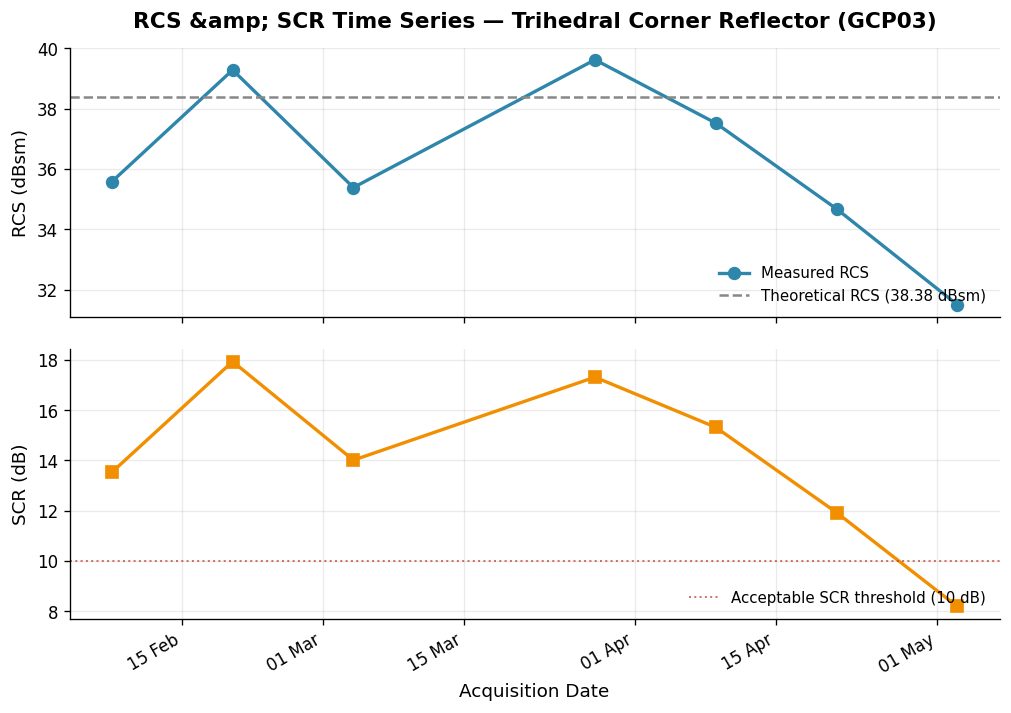

Figure saved to: /media/geospasial/storage_2/TESISZAKI/Radiometric/CoRAL-modif/RCS_SCR_timeseries.png


In [12]:
THEORETICAL_RCS_DBSM = 38.38

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                gridspec_kw={"hspace": 0.12})

ax1.plot(df["Date"], df["RCS (dBsm)"], marker="o", markersize=7,
         linewidth=2, color="#2E86AB", label="Measured RCS")
ax1.axhline(THEORETICAL_RCS_DBSM, color="#888888", linestyle="--", linewidth=1.5,
            label=f"Theoretical RCS ({THEORETICAL_RCS_DBSM:.2f} dBsm)")
ax1.set_ylabel("RCS (dBsm)", fontsize=11)
ax1.set_title(f"RCS &amp; SCR Time Series — Trihedral Corner Reflector ({GCP_NAME})",
              fontsize=13, fontweight="bold", pad=12)
ax1.legend(loc="lower right", frameon=False, fontsize=9)

ax2.plot(df["Date"], df["SCR (dB)"], marker="s", markersize=7,
         linewidth=2, color="#F18F01")
ax2.axhline(10, color="#c0392b", linestyle=":", linewidth=1.2, alpha=0.7,
            label="Acceptable SCR threshold (10 dB)")
ax2.set_ylabel("SCR (dB)", fontsize=11)
ax2.set_xlabel("Acquisition Date", fontsize=11)
ax2.legend(loc="lower right", frameon=False, fontsize=9)

for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, pos: pd.to_datetime(x, unit="D", origin="1970-01-01").strftime("%d %b")))

fig.autofmt_xdate(rotation=30)
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "RCS_SCR_timeseries.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {plot_path}")

## 10. Spatial Visualization: Target Chip per Scene

Each panel shows the mean-intensity image (dB) around the CR for one scene. The yellow box marks the clutter window and the red box marks the target window.

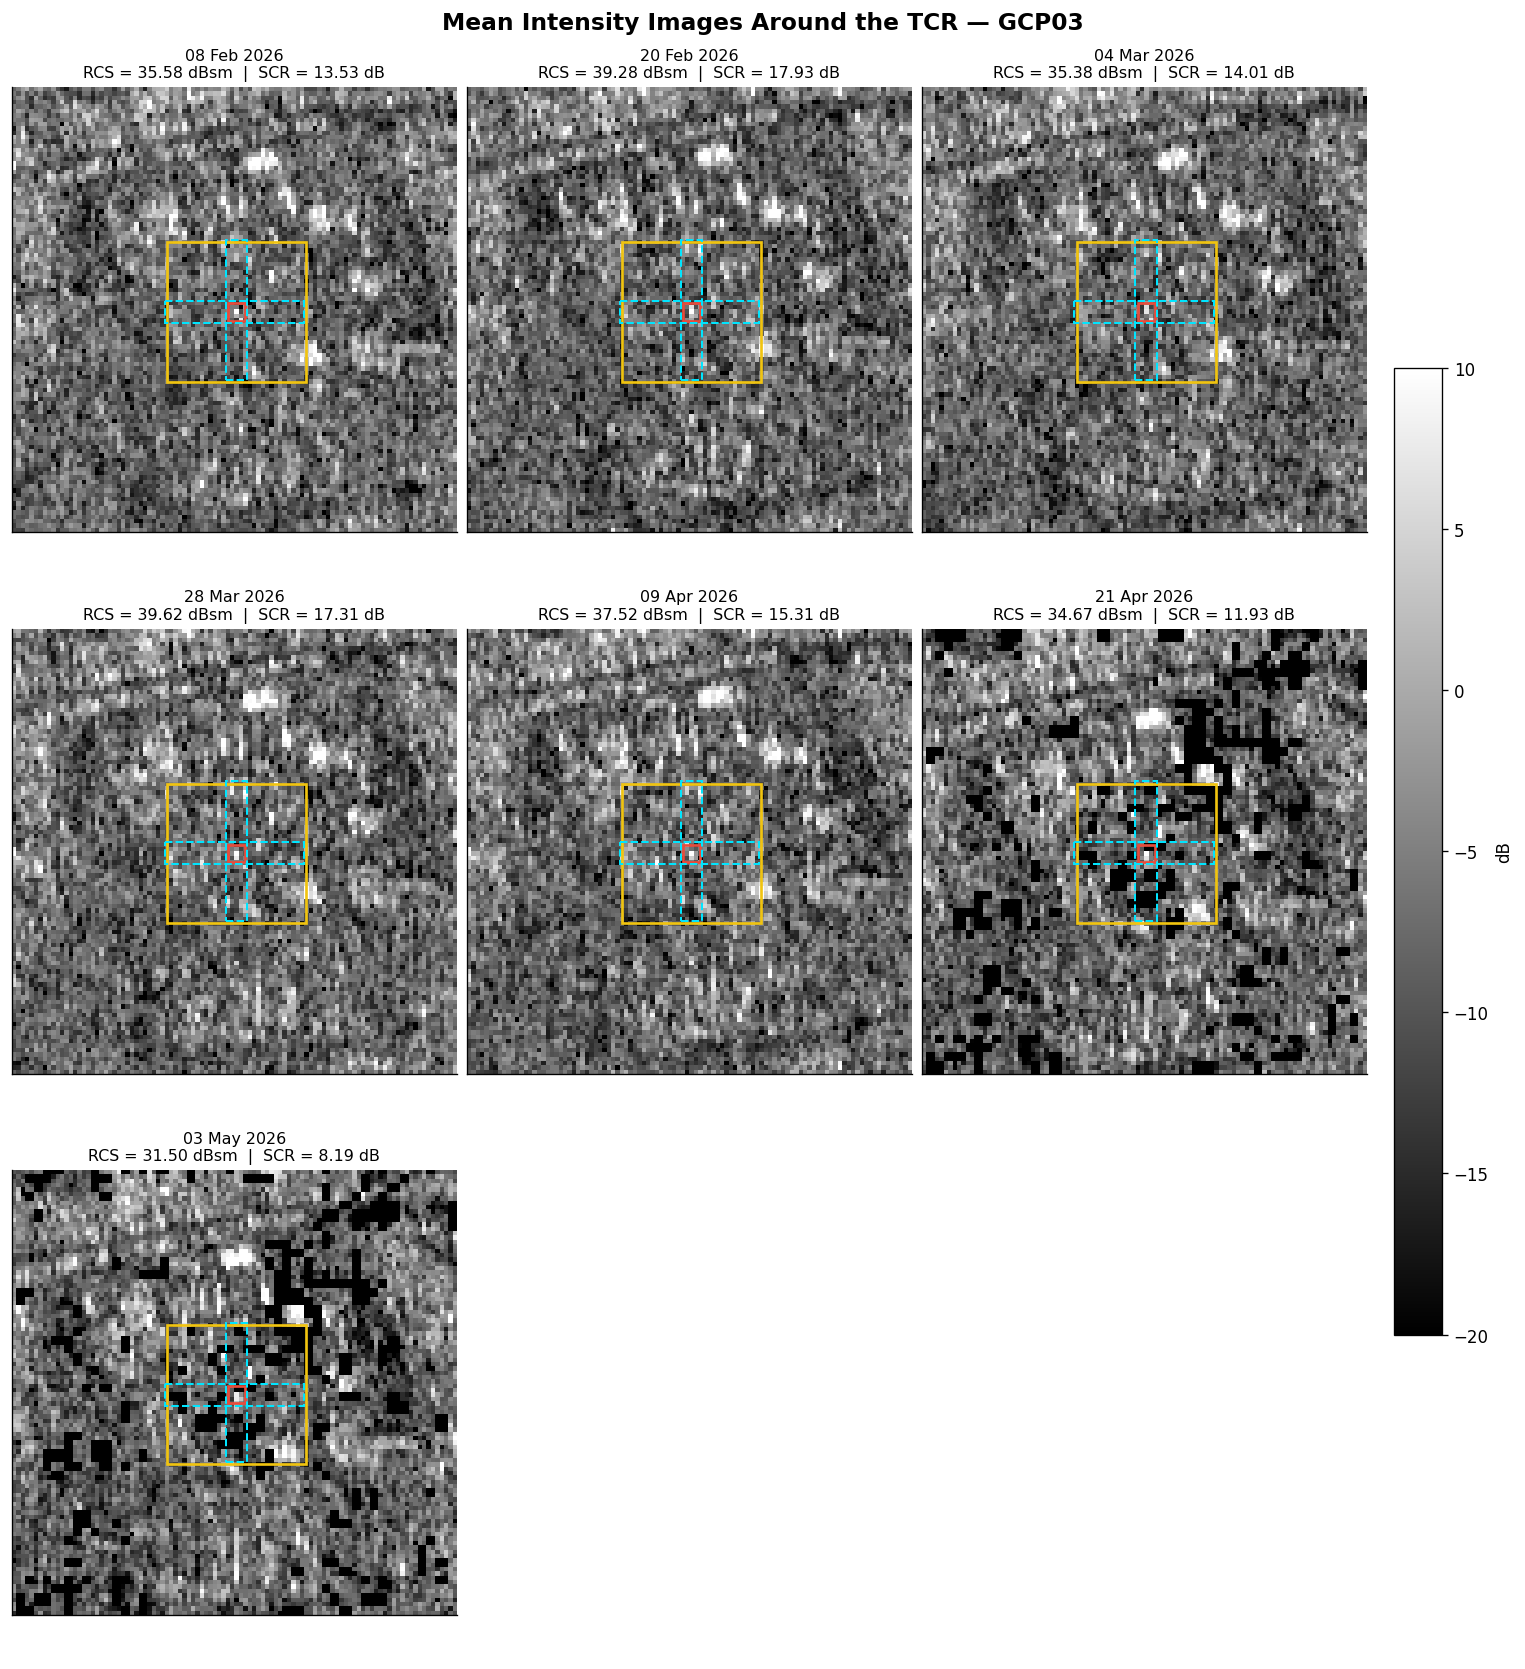

Grid figure saved to: /media/geospasial/storage_2/TESISZAKI/Radiometric/CoRAL-modif/RCS_timeseries_grid_crossexclusion.png


In [13]:
n_scenes = len(files)
n_cols = min(n_scenes, 3)
n_rows = int(np.ceil(n_scenes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2*n_cols, 4.6*n_rows),
                          constrained_layout=True)
axes = np.atleast_1d(axes).flatten()

for i, f in enumerate(files):
    scene_name = os.path.basename(f)
    band = band_map[scene_name]
    date_str = pd.to_datetime(scene_name.split("_")[5][:8], format="%Y%m%d").strftime("%d %b %Y")
    peak = peak_positions[scene_name]
    site_pos = np.array([peak["range"], peak["azimuth"]])

    data_dir = f.replace(".dim", ".data")
    band_path = os.path.join(data_dir, f"{band}.img")

    with rasterio.open(band_path) as src:
        d = src.read(1, window=Window(site_pos[0]-SUB_IM, site_pos[1]-SUB_IM, SUB_IM*2, SUB_IM*2))

    db = 10*np.log10(np.clip(d, 1e-10, None))

    ax = axes[i]
    im = ax.matshow(db, cmap="gray", vmin=-20, vmax=10)
    ax.set_title(f"{date_str}\nRCS = {rcs[i]:.2f} dBsm  |  SCR = {scr[i]:.2f} dB", fontsize=9.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.xaxis.set_ticks_position("bottom")

    center = SUB_IM

    # Clutter window (yellow) — outer boundary before cross-exclusion
    half_clt = CLT_WIN_SZ // 2
    ax.add_patch(plt.Rectangle((center-half_clt, center-half_clt), CLT_WIN_SZ, CLT_WIN_SZ,
                                edgecolor="#f1c40f", facecolor="none", linewidth=1.6))

    # Target window (red)
    half_targ = TARG_WIN_SZ // 2
    ax.add_patch(plt.Rectangle((center-half_targ, center-half_targ), TARG_WIN_SZ, TARG_WIN_SZ,
                                edgecolor="#e74c3c", facecolor="none", linewidth=1.6))

    # Cross-exclusion overlay (cyan) — the plus-shaped region excluded from clutter,
    # per Garthwaite et al. (2015) Figure 4.11
    half_cross = CROSS_WIDTH / 2
    ax.axvspan(center-half_cross, center+half_cross,
               ymin=(center-half_clt)/db.shape[0], ymax=(center+half_clt)/db.shape[0],
               edgecolor="#00e5ff", facecolor="none", linewidth=1.2, linestyle="--")
    ax.axhspan(center-half_cross, center+half_cross,
               xmin=(center-half_clt)/db.shape[1], xmax=(center+half_clt)/db.shape[1],
               edgecolor="#00e5ff", facecolor="none", linewidth=1.2, linestyle="--")

for j in range(i+1, len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Mean Intensity Images Around the TCR — {GCP_NAME}", fontsize=14, fontweight="bold")
cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.6, pad=0.02, label="dB")

grid_path = os.path.join(OUTPUT_DIR, "RCS_timeseries_grid_crossexclusion.png")
plt.savefig(grid_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Grid figure saved to: {grid_path}")

## 11. Summary

| File | Description |
|---|---|
| `RCS_results.csv` | Full table of RCS, SCR, resolved band, and pixel position per scene |
| `RCS_SCR_timeseries.png` | Time-series plot of RCS and SCR |
| `RCS_timeseries_grid.png` | Grid visualization of the target chip per scene |

**Interpretation notes:**
- RCS values close to the theoretical value (38.38 dBsm) indicate that the TCR is functioning optimally and is unobstructed.
- SCR &lt; 10 dB indicates that the target signal approaches the clutter level; results for such scenes should be interpreted with caution (possible obstruction, misalignment, or environmental interference).
- Scenes flagged as *split / single subswath* in Section 3 were terrain-corrected from a single IW subswath only; their resolved band name (`Sigma0_IW{n}_VV`) differs from full-swath scenes (`Sigma0_VV`), but RCS/SCR values remain directly comparable across both product types.
